# Optimality gap analysis — exact optimum, k-swap, and MILP

Loads every JSON in `results/exact_optimum/` and analyses:

1. **UTD19 protocol-true optimum** (`exact_optimum_*seeds.json`, from `experiment_exact_optimum.py`) — exhaustive minimum |S| vs each greedy/k-swap method.
2. **MILP oracle-routing optimum** (`milp_optimum_*.json`, from `experiment_milp_optimum.py`) — certified lower bound; the gap to the protocol optimum is the *price of honest splitting*.
3. **Synthetic instances** (`synthetic_optimum.json`, from `experiment_synthetic_optimum.py`) — fraction-optimal per method on the replay instances.

Re-run this notebook after pulling server results — it picks up whatever files exist.

In [1]:
import json, os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
RESULT_DIR = os.path.join(ROOT, "results", "exact_optimum")
files = sorted(glob.glob(os.path.join(RESULT_DIR, "*.json")))
print("found:", *[os.path.basename(f) for f in files], sep="\n  ")

found:
  exact_optimum_3seeds.json


## 1. UTD19: protocol-true optimum vs greedy / k-swap

In [2]:
exact_files = [f for f in files if os.path.basename(f).startswith("exact_optimum")]
assert exact_files, "run experiment_exact_optimum.py first"
# Prefer the largest run (most seeds)
exact_path = max(exact_files, key=lambda f: json.load(open(f))["config"]["n_seeds"])
exact = json.load(open(exact_path))
print("using:", os.path.basename(exact_path), "| config:", exact["config"])

rec = pd.json_normalize(exact["records"])
methods = exact["config"]["greedy_configs"]
size_cols = {m: f"greedy_sizes.{m}" for m in methods}
table = rec.groupby("gamma").agg(
    opt=("opt_size", "mean"),
    **{m: (c, "mean") for m, c in size_cols.items()},
).round(2)
table

using: exact_optimum_3seeds.json | config: {'n_models_total': 20, 'subset_size': 12, 'n_seeds': 3, 'gammas': [60.0, 80.0, 100.0, 120.0, 140.0, 160.0], 'metric': 'mean_abs', 'greedy_configs': ['backward', 'forward', 'main', 'backward_kswap2', 'backward_kswap3']}


,opt,backward,forward,main,backward_kswap2,backward_kswap3
gamma,,,,,,
60.0,8.67,9.33,11.33,9.00,8.67,8.67
80.0,5.00,5.67,9.67,6.67,5.33,5.00
100.0,3.00,3.67,5.67,4.00,3.00,3.00
120.0,2.33,2.67,3.00,2.67,2.33,2.33
140.0,1.33,2.00,2.00,1.67,1.33,1.33
160.0,1.33,2.00,1.33,1.33,1.33,1.33


In [3]:
gap_table = table[methods].sub(table["opt"], axis=0).round(2)
gap_table.columns = [f"gap_{m}" for m in methods]
gap_table

,gap_backward,gap_forward,gap_main,gap_backward_kswap2,gap_backward_kswap3
gamma,,,,,
60.0,0.66,2.66,0.33,0.00,0.0
80.0,0.67,4.67,1.67,0.33,0.0
100.0,0.67,2.67,1.00,0.00,0.0
120.0,0.34,0.67,0.34,0.00,0.0
140.0,0.67,0.67,0.34,0.00,0.0
160.0,0.67,0.00,0.00,0.00,0.0


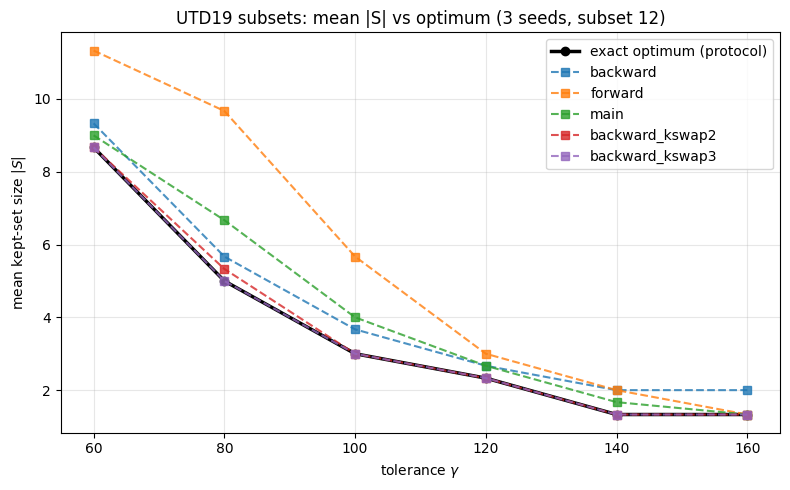

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(table.index, table["opt"], "k-o", lw=2.5, label="exact optimum (protocol)")
for m in methods:
    ax.plot(table.index, table[m], "--s", alpha=0.8, label=m)
ax.set_xlabel(r"tolerance $\gamma$"); ax.set_ylabel("mean kept-set size $|S|$")
ax.set_title(f"UTD19 subsets: mean |S| vs optimum ({exact['config']['n_seeds']} seeds, "
             f"subset {exact['config']['subset_size']})")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [5]:
# Per-instance: how often is each method exactly optimal?
frac_opt = pd.DataFrame({
    m: (rec[size_cols[m]] == rec["opt_size"]).groupby(rec["gamma"]).mean()
    for m in methods
}).round(3)
frac_opt.loc["ALL"] = [float((rec[size_cols[m]] == rec["opt_size"]).mean()) for m in methods]
frac_opt

,backward,forward,main,backward_kswap2,backward_kswap3
gamma,,,,,
60.0,0.667,0.000000,0.667000,1.000000,1.0
80.0,0.667,0.000000,0.333000,0.667000,1.0
100.0,0.333,0.000000,0.333000,1.000000,1.0
120.0,0.667,0.667000,0.667000,1.000000,1.0
140.0,0.333,0.667000,0.667000,1.000000,1.0
160.0,0.333,1.000000,1.000000,1.000000,1.0
ALL,0.500,0.388889,0.611111,0.944444,1.0


## 2. MILP oracle optimum — the price of honest splitting

The MILP picks routing weights directly against `Y_eval` (an oracle router), so
`|OPT_milp| <= |OPT_protocol|`. The difference measures how much the honest
fit/eval split costs relative to the best certificate that exists at all.

In [6]:
milp_files = [f for f in files if os.path.basename(f).startswith("milp_optimum")]
if not milp_files:
    print("no MILP results yet -- run experiment_milp_optimum.py (server for subset >= 15)")
else:
    milp_payloads = [json.load(open(f)) for f in milp_files]
    # only join MILP runs on the same subset size as the exact run
    milp_payloads = [p for p in milp_payloads
                     if p["config"]["subset_size"] == exact["config"]["subset_size"]]
    milp = pd.concat([pd.json_normalize(p["records"]) for p in milp_payloads]) \
        if milp_payloads else pd.DataFrame(columns=["seed","gamma","milp_size","solve_time_s"])
    joined = rec.merge(milp[["seed", "gamma", "milp_size", "solve_time_s"]],
                       on=["seed", "gamma"], how="inner")
    if len(joined) == 0:
        print("MILP and exact runs use different seeds/subsets -- showing MILP alone")
        display(milp.groupby("gamma")[["milp_size", "solve_time_s"]].mean().round(2))
    else:
        cmp = joined.groupby("gamma").agg(
            milp_oracle=("milp_size", "mean"),
            protocol_opt=("opt_size", "mean"),
            backward_kswap2=(size_cols.get("backward_kswap2", "opt_size"), "mean"),
        ).round(2)
        cmp["price_of_honesty"] = (cmp["protocol_opt"] - cmp["milp_oracle"]).round(2)
        display(cmp)
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(cmp.index, cmp["milp_oracle"], "-^", label="MILP oracle optimum (lower bound)")
        ax.plot(cmp.index, cmp["protocol_opt"], "k-o", lw=2.5, label="protocol optimum")
        ax.fill_between(cmp.index, cmp["milp_oracle"], cmp["protocol_opt"], alpha=0.15,
                        label="price of honest splitting")
        ax.set_xlabel(r"$\gamma$"); ax.set_ylabel("mean $|S|$"); ax.legend(); ax.grid(alpha=0.3)
        ax.set_title("Oracle (MILP) vs protocol-true optimum")
        plt.tight_layout(); plt.show()

no MILP results yet -- run experiment_milp_optimum.py (server for subset >= 15)


## 3. Synthetic replay instances: fraction optimal per method

In [7]:
syn_path = os.path.join(RESULT_DIR, "synthetic_optimum.json")
if not os.path.exists(syn_path):
    print("no synthetic results yet -- run experiment_synthetic_optimum.py")
else:
    syn = pd.DataFrame(json.load(open(syn_path))["records"])
    method_cols = [c for c in syn.columns
                   if c not in ("dim", "N", "seed", "gamma", "opt", "was_worse_case")]
    stats = []
    for label, part in [("random sample", syn[~syn.was_worse_case]),
                        ("hard cases", syn[syn.was_worse_case])]:
        for m in method_cols:
            gap = part[m] - part["opt"]
            stats.append({"sample": label, "method": m, "n": len(part),
                          "mean_gap": round(gap.mean(), 4),
                          "frac_optimal": round((gap == 0).mean(), 4)})
    stats = pd.DataFrame(stats)
    display(stats.pivot(index="method", columns="sample",
                        values=["frac_optimal", "mean_gap"]).round(4))

    fig, ax = plt.subplots(figsize=(8, 4))
    sub = stats[stats["sample"] == "random sample"].sort_values("frac_optimal")
    ax.barh(sub["method"], sub["frac_optimal"])
    ax.axvline(1.0, color="k", ls=":", lw=1)
    ax.set_xlabel("fraction of instances solved to exact optimality (random sample)")
    ax.set_xlim(0, 1.05); ax.grid(alpha=0.3, axis="x")
    plt.tight_layout(); plt.show()

no synthetic results yet -- run experiment_synthetic_optimum.py


## Takeaways template (fill in after server runs)

- Backward + k-swap(k=2) achieves the exact protocol optimum on … % of instances; k=3 on … %.
- The only k=2 failures are optima sharing zero models with the backward seed (the k=3 move).
- Forward's worst gap is +… at γ=…, consistent with the non-submodularity of E(S) = max-residual.
- MILP oracle bound: protocol optimum pays +… models on average for honest splitting.